CLEANING

In [2]:
import pandas as pd

df = pd.read_csv('mushroom.data')
print(df.head())
print(df.shape)

   p  x  s  n  t p.1  f  c n.1  k  ... s.2  w w.1 p.2 w.2  o p.3 k.1 s.3  u
0  e  x  s  y  t   a  f  c   b  k  ...   s  w   w   p   w  o   p   n   n  g
1  e  b  s  w  t   l  f  c   b  n  ...   s  w   w   p   w  o   p   n   n  m
2  p  x  y  w  t   p  f  c   n  n  ...   s  w   w   p   w  o   p   k   s  u
3  e  x  s  g  f   n  f  w   b  k  ...   s  w   w   p   w  o   e   n   a  g
4  e  x  y  y  t   a  f  c   b  n  ...   s  w   w   p   w  o   p   k   n  g

[5 rows x 23 columns]
(8123, 23)


In [3]:
df.columns = ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 
 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 
 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 
 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 
 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

In [4]:
print(df.isnull().sum())

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


In [5]:
print(df['class'].value_counts())

class
e    4208
p    3915
Name: count, dtype: int64


In [6]:
print(df['cap-shape'].value_counts())

cap-shape
x    3655
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64


In [7]:
print(df['cap-surface'].value_counts())

cap-surface
y    3244
s    2555
f    2320
g       4
Name: count, dtype: int64


In [8]:
cols = ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 
 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 
 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 
 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 
 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

for col in cols:
    print(df[col].value_counts())

class
e    4208
p    3915
Name: count, dtype: int64
cap-shape
x    3655
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64
cap-surface
y    3244
s    2555
f    2320
g       4
Name: count, dtype: int64
cap-color
n    2283
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
u      16
r      16
Name: count, dtype: int64
bruises
f    4748
t    3375
Name: count, dtype: int64
odor
n    3528
f    2160
y     576
s     576
a     400
l     400
p     255
c     192
m      36
Name: count, dtype: int64
gill-attachment
f    7913
a     210
Name: count, dtype: int64
gill-spacing
c    6811
w    1312
Name: count, dtype: int64
gill-size
b    5612
n    2511
Name: count, dtype: int64
gill-color
b    1728
p    1492
w    1202
n    1048
g     752
h     732
u     492
k     407
e      96
y      86
o      64
r      24
Name: count, dtype: int64
stalk-shape
t    4608
e    3515
Name: count, dtype: int64
stalk-root
b    3776
?    2480
e    1119
c     556
r     192
Name: coun

In [9]:
import numpy as np

df = df.replace('?', np.nan)

In [10]:
print(df.isnull().sum())

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64


SPLITTLING THE DATA BEFORE FILLING  IN THE MISSING VALUES.

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [12]:
mode_val = df['stalk-root'].mode()[0]
X_train['stalk-root'] = X_train['stalk-root'].fillna(mode_val)
X_test['stalk-root'] = X_test['stalk-root'].fillna(mode_val)

NOW ONE HOT ENCODING

In [13]:
X_train = pd.get_dummies(X_train, columns= ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 
    'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 
    'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 
    'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat'], drop_first= True)
X_test = pd.get_dummies(X_test, columns = ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 
    'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 
    'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 
    'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat'], drop_first = True)

In [14]:
print(X_train.shape)
print(X_test.shape)

(6498, 94)
(1625, 92)


In [15]:
X_train, X_test = X_train.align(X_test, join = 'left', axis = 1, fill_value=0)

In [16]:
print(X_train.shape)
print(X_test.shape)

(6498, 94)
(1625, 94)


NOW TRAINING THE MODEL 

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state= 42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc =  accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name}: Train: {train_acc}, Test: {test_acc}")

Logistic Regression: Train: 1.0, Test: 1.0
Decision Tree: Train: 0.9967682363804248, Test: 0.9963076923076923
Random Forest: Train: 1.0, Test: 1.0


In [18]:
for name, model in models.items():
    if name == 'Logistic Regression':
        continue
    print(pd.Series(model.feature_importances_, index =  X_train.columns).sort_values())

cap-shape_f                   0.000000
cap-shape_k                   0.000000
cap-shape_s                   0.000000
cap-shape_x                   0.000000
cap-surface_y                 0.000000
                                ...   
odor_l                        0.022284
spore-print-color_r           0.031376
stalk-surface-below-ring_y    0.103913
stalk-root_c                  0.178546
odor_n                        0.625715
Length: 94, dtype: float64
spore-print-color_y           0.000000
spore-print-color_o           0.000000
cap-shape_c                   0.000092
gill-color_k                  0.000194
veil-color_o                  0.000253
                                ...   
odor_f                        0.051234
stalk-surface-above-ring_k    0.052346
spore-print-color_h           0.061248
gill-size_n                   0.118252
odor_n                        0.122786
Length: 94, dtype: float64


CROSS VALIDATION

In [19]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv = 5)
    print(f"{name}: {scores.mean()} (+/- {scores.std()})")

Logistic Regression: 0.9995381062355658 (+/- 0.0006158583525789074)
Decision Tree: 0.9967680464262451 (+/- 0.0008978827789409072)
Random Forest: 1.0 (+/- 0.0)


so this is basically the test of the model in 5 different distribution of train and test data and gives the av. accuracy of the entire dataset.
doesn't affect the model at all.

We choose RandomForest to fine tune or (GridSearchCV) to find the proper parameter for the model.


In [20]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth" : [None, 5, 10, 20],
    "min_samples_split": [2, 5]
}


In [21]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv = 5, 
    n_jobs= -1,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >

In [22]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
1.0


In [23]:
best_model = grid.best_estimator_

In [24]:
print(best_model.score(X_test, y_test))

1.0


NOW TRYING ON DECISION TREE

In [25]:
dt_param_grid = {
    "max_depth": [3, 5, 10, None], 
    "min_samples_split": [2, 5, 10]
}

In [26]:
dt_grid =  GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv = 5, 
    n_jobs= -1
)
dt_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3

In [27]:
print(dt_grid.best_params_)
print(dt_grid.best_score_)

{'max_depth': 10, 'min_samples_split': 2}
1.0


In [28]:
best_model = grid.best_estimator_
print(best_model.score(X_test, y_test))

1.0


SAVING THE MODEL

In [29]:
import joblib

joblib.dump(best_model, "mushroom_rf_model.pkl")

['mushroom_rf_model.pkl']

LOADING THE MODEL

In [30]:
loaded_model = joblib.load("mushroom_rf_model.pkl")

y_pred  = loaded_model.predict(X_test)
print(loaded_model.score(X_test, y_test))

1.0


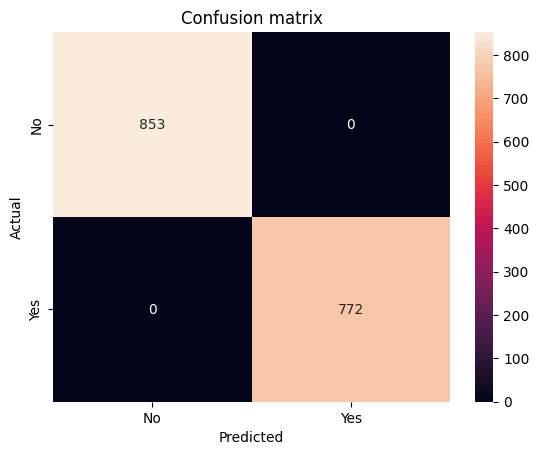

In [31]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test,  y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', xticklabels= ["No", "Yes"], yticklabels=["No", "Yes"] )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()